# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# High field Landau fan 

In [4]:
def plot_landau_fan(fig, ax, norm, cmap="viridis", files=[1960]):
    for file in files:
        contact = 1 # choose which contact pair to plot = 1,2,3  
        data = sl.pload(file_path, file)
        md = sl.load_meta(file_path, file)
        ys = data['ys'][0]
        print(ys.max())
        zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
        
        Vtgs = data['xs'][0]
        Vbgs = data['xs'][1]
        xs, D_vec = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
        print("D", D_vec[0])
        plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True)
        ax.set_ylim(0, 12)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

## D = 1

5.0
D 0.9951133459733648
12.0
D 0.9950728019081713


['/home/aaron/Fermiology-and-the-cCSC/figs/landau_fan_1vnm.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/landau_fan_1vnm.png']

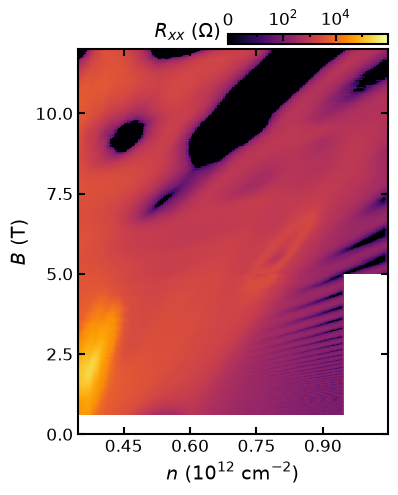

In [5]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1840, 1959])

pos = ax.get_position()
cb_width = 0.4  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, "landau_fan_1vnm")

## D = 0.95

12.0
D 0.9453576786746966


['/home/aaron/Fermiology-and-the-cCSC/figs/landau_fan_095vnm.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/landau_fan_095vnm.png']

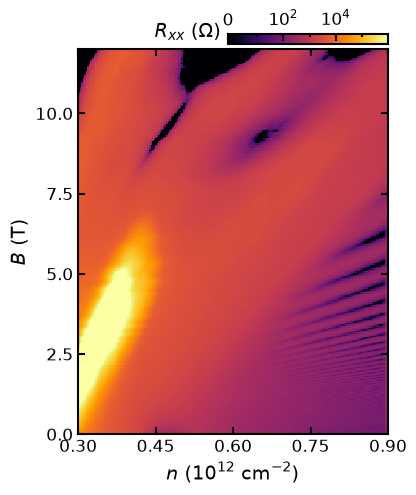

In [6]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1960])

pos = ax.get_position()
cb_width = 0.4  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, "landau_fan_095vnm")

# Full figure


5.0
D 0.9951133459733648
12.0
D 0.9950728019081713
12.0
D 0.9453576786746966


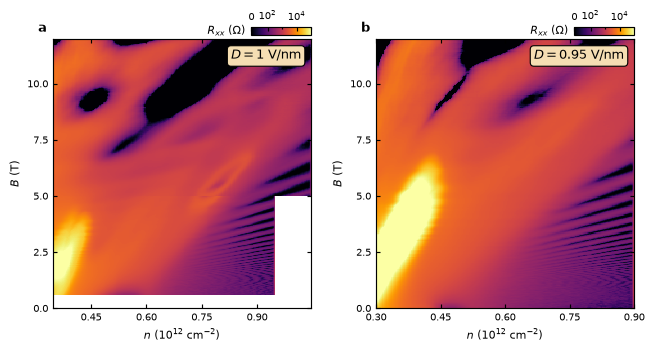

In [7]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(1, 2, figure=fig,   
                       width_ratios=[1, 1],
                       height_ratios=[1],
                       hspace=0.4, wspace=0.25)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + 1*label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E5)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1840, 1959])
ax.text(0.96, 0.96, r'$D = 1$ V/nm', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + 1*label_spacer, "b", fontweight='bold')

plot = plot_landau_fan(fig, ax, norm, "inferno", [1960])
ax.text(0.96, 0.96, r'$D = 0.95$ V/nm', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

plt.show()
fig.savefig("si-fig-high-field-fans.pdf", dpi=300, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default